Oto 5 pierwszych wierszy z naszego zbioru:


,Tytul,Dzielnica,Cena_PLN,Powierzchnia_m2,Cena_za_m2
0,Brak tytułu,Zaspa Młyniec - Odświeżono dnia,899500,45.00,19988.89
1,Brak tytułu,Nieznana,2599000,83.30,31200.48
2,Brak tytułu,Ujeścisko - Łostowice - Odświeżono dzisiaj o,749000,53.00,14132.08
3,Brak tytułu,Jasień - Odświeżono dzisiaj o,659000,47.10,13991.51
4,Brak tytułu,Ujeścisko - Łostowice - Odświeżono dzisiaj o,489000,37.07,13191.26



Statystyki opisowe dla Ceny za m²:


count       50.00
mean     14366.05
std       6664.16
min          0.63
25%      11740.30
50%      13591.38
75%      17668.39
max      41406.25
Name: Cena_za_m2, dtype: float64

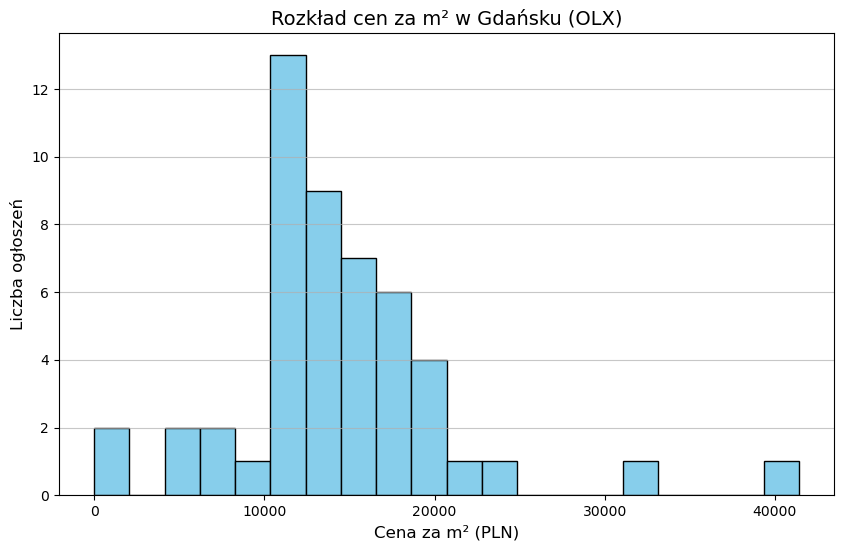

Index(['Tytul', 'Dzielnica', 'Cena_PLN', 'Powierzchnia_m2', 'Cena_za_m2'], dtype='object')


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytujemy nasz wygenerowany plik z dysku
df = pd.read_excel('OLX_Mieszkania_Gdansk.xlsx')

# 2. Sprawdzamy, jak wyglądają dane (w Jupiterze używamy display zamiast print dla ładnego wyglądu)
print("Oto 5 pierwszych wierszy z naszego zbioru:")
display(df.head())

# 3. Szybka matematyka - statystyki opisowe dla kolumny z ceną za metr
print("\nStatystyki opisowe dla Ceny za m²:")
display(df['Cena_za_m2'].describe().round(2))

# 4. Rysujemy nasz pierwszy wykres! Histogram rozkładu cen
plt.figure(figsize=(10, 6))
plt.hist(df['Cena_za_m2'], bins=20, color='skyblue', edgecolor='black')
plt.title('Rozkład cen za m² w Gdańsku (OLX)', fontsize=14)
plt.xlabel('Cena za m² (PLN)', fontsize=12)
plt.ylabel('Liczba ogłoszeń', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.show()
df = pd.read_excel('OLX_Mieszkania_Gdansk.xlsx')
print(df.columns) # To pokaże nam dokładnie, jakie kolumny wczytał Python

In [2]:
print(f"Liczba wierszy przed czyszczeniem: {len(df)}")

# 1. Usuwamy klony (duplikaty) - Pandas sam znajdzie identyczne wiersze i zostawi tylko jeden
df = df.drop_duplicates()

# 2. Naprawiamy Dzielnice
# Rozbijamy tekst na kawałki używając myślnika '-' i bierzemy tylko pierwszą część (przed myślnikiem)
# Na koniec usuwamy niepotrzebne spacje za pomocą .str.strip()
df['Dzielnica'] = df['Dzielnica'].str.split('-').str[0].str.strip()

# 3. Wyrzucamy mieszkania bez podanej dzielnicy (nie przydadzą się modelowi)
df = df[df['Dzielnica'] != 'Nieznana']

print(f"Liczba wierszy po czyszczeniu: {len(df)}")
print("-" * 50)
print("Oto nasza czyściutka tabela:")
display(df[['Dzielnica', 'Cena_PLN', 'Powierzchnia_m2', 'Cena_za_m2']].head(10))

Liczba wierszy przed czyszczeniem: 50
Liczba wierszy po czyszczeniu: 33
--------------------------------------------------
Oto nasza czyściutka tabela:


,Dzielnica,Cena_PLN,Powierzchnia_m2,Cena_za_m2
0,Zaspa Młyniec,899500,45.00,19988.89
2,Ujeścisko,749000,53.00,14132.08
3,Jasień,659000,47.10,13991.51
4,Ujeścisko,489000,37.07,13191.26
7,Jasień,799000,75.00,10653.33
8,Piecki,743000,62.50,11888.00
9,Wrzeszcz,630000,37.00,17027.03
10,Krakowiec,299000,38.75,7716.13
11,Stogi z Przeróbką,419000,26.27,15949.75
12,Strzyża,1199000,67.05,17882.18


Liczba ogłoszeń przed czyszczeniem: 33
Liczba ogłoszeń po czyszczeniu (usunięte anomalie): 32
--------------------------------------------------


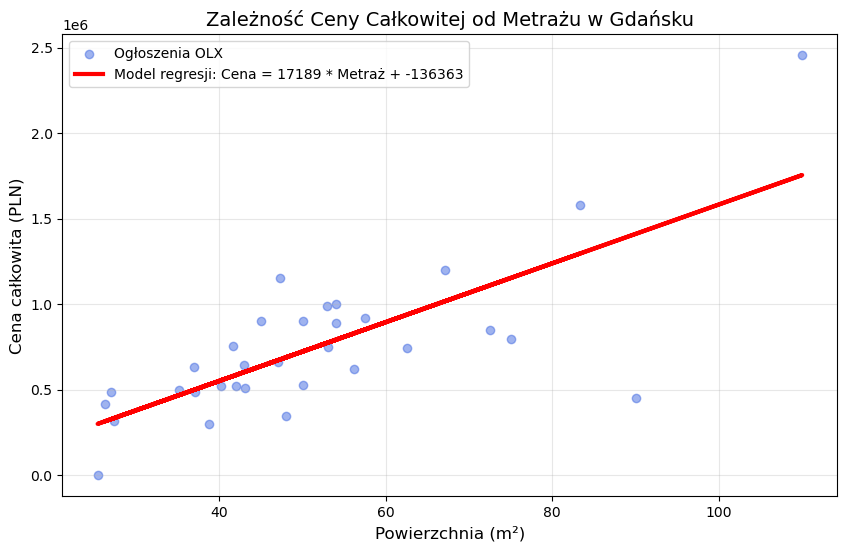

In [3]:
import numpy as np

# 1. Filtrowanie (usuwamy anomalie pow. 30 000 zł/m2)
df_czyste = df[df['Cena_za_m2'] < 30000].copy()

print(f"Liczba ogłoszeń przed czyszczeniem: {len(df)}")
print(f"Liczba ogłoszeń po czyszczeniu (usunięte anomalie): {len(df_czyste)}")
print("-" * 50)

# 2. Wykres rozrzutu (Scatter plot) z linią regresji (MNK)
plt.figure(figsize=(10, 6))

# Rysujemy niebieskie punkty (mieszkania)
x = df_czyste['Powierzchnia_m2']
y = df_czyste['Cena_PLN']
plt.scatter(x, y, alpha=0.5, color='royalblue', label='Ogłoszenia OLX')

# 3. Klasyczna Regresja Liniowa (MNK wbudowane w numpy)
# polyfit(x, y, 1) szuka wielomianu 1 stopnia, czyli prostej: y = a*x + b
a, b = np.polyfit(x, y, 1)

# Rysujemy czerwoną linię trendu
plt.plot(x, a*x + b, color='red', linewidth=3, label=f'Model regresji: Cena = {a:.0f} * Metraż + {b:.0f}')

# Formatowanie wykresu
plt.title('Zależność Ceny Całkowitej od Metrażu w Gdańsku', fontsize=14)
plt.xlabel('Powierzchnia (m²)', fontsize=12)
plt.ylabel('Cena całkowita (PLN)', fontsize=12)
#plt.ticklabel_format(style='plain', axis='y') # Wyłącza notację naukową (np. 1e6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Liczba ogłoszeń przed czyszczeniem: 33
Liczba ogłoszeń po czyszczeniu (usunięte anomalie): 31


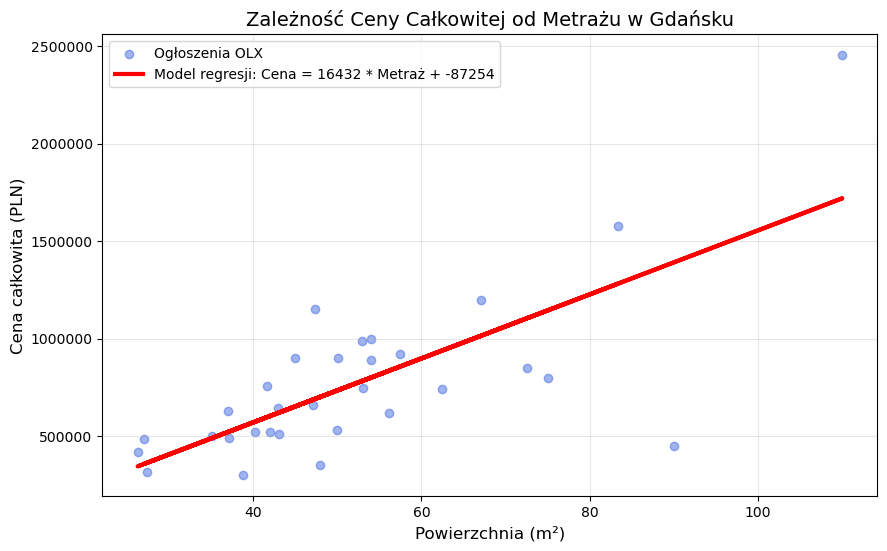

In [4]:
import numpy as np

# 1. Filtrowanie (usuwamy anomalie pow. 30 000 zł/m2) PLUS nowy warunek
df_czyste = df[(df['Cena_za_m2'] < 30000) & (df['Cena_PLN'] > 150000 )].copy()

print(f"Liczba ogłoszeń przed czyszczeniem: {len(df)}")
print(f"Liczba ogłoszeń po czyszczeniu (usunięte anomalie): {len(df_czyste)}")

# 2. Wykres rozrzutu (Scatter plot) z linią regresji (MNK)
plt.figure(figsize=(10, 6))

# Rysujemy niebieskie punkty (mieszkania)
x = df_czyste['Powierzchnia_m2']
y = df_czyste['Cena_PLN']
plt.scatter(x, y, alpha=0.5, color='royalblue', label='Ogłoszenia OLX')

# 3. Klasyczna Regresja Liniowa (MNK wbudowane w numpy)
# polyfit(x, y, 1) szuka wielomianu 1 stopnia, czyli prostej: y = a*x + b
a, b = np.polyfit(x, y, 1)

# Rysujemy czerwoną linię trendu
plt.plot(x, a*x + b, color='red', linewidth=3, label=f'Model regresji: Cena = {a:.0f} * Metraż + {b:.0f}')

# Formatowanie wykresu
plt.title('Zależność Ceny Całkowitej od Metrażu w Gdańsku', fontsize=14)
plt.xlabel('Powierzchnia (m²)', fontsize=12)
plt.ylabel('Cena całkowita (PLN)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Wyłącza notację naukową (np. 1e6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
print(f"Liczba wierszy przed czyszczeniem: {len(df)}")

# 1. Usuwamy duplikaty
df = df.drop_duplicates()

# 2. Naprawiamy Dzielnice (ucinamy tekst od myślnika w prawo)
df['Dzielnica'] = df['Dzielnica'].str.split('-').str[0].str.strip()

# 3. Wyrzucamy mieszkania bez podanej dzielnicy i te "za grosze"
df = df[df['Dzielnica'] != 'Nieznana']
df = df[(df['Cena_za_m2'] < 30000) & (df['Cena_PLN'] > 150000)]

print(f"Liczba wierszy po czyszczeniu: {len(df)}")
print("-" * 50)
print("Oto nasza czyściutka tabela:")
display(df[['Dzielnica', 'Cena_PLN', 'Powierzchnia_m2', 'Cena_za_m2']].head(10))

Liczba wierszy przed czyszczeniem: 33
Liczba wierszy po czyszczeniu: 31
--------------------------------------------------
Oto nasza czyściutka tabela:


,Dzielnica,Cena_PLN,Powierzchnia_m2,Cena_za_m2
0,Zaspa Młyniec,899500,45.00,19988.89
2,Ujeścisko,749000,53.00,14132.08
3,Jasień,659000,47.10,13991.51
4,Ujeścisko,489000,37.07,13191.26
7,Jasień,799000,75.00,10653.33
8,Piecki,743000,62.50,11888.00
9,Wrzeszcz,630000,37.00,17027.03
10,Krakowiec,299000,38.75,7716.13
11,Stogi z Przeróbką,419000,26.27,15949.75
12,Strzyża,1199000,67.05,17882.18


In [6]:
# Tworzymy słownik, który tłumaczy język portalu OLX na język map Google/OpenStreetMap
tlumacz_dzielnic = {
    "Stogi z Przeróbką": "Stogi",
    "Chełm z dzielnicą Gdańsk Południe": "Chełm",
    "Krakowiec - Górki Zachodnie": "Krakowiec",
    "Orunia - Św": "Orunia",
    "Orunia": "Orunia", # Czasami OLX ucina nazwy
    "Piecki": "Piecki-Migowo",
    "Zaspa Młyniec": "Zaspa"
}

# Używamy metody .replace(), która przejdzie przez naszą kolumnę 
# i podmieni błędne nazwy na te z naszego słownika
df['Dzielnica'] = df['Dzielnica'].replace(tlumacz_dzielnic)

print("Tłumaczenie zakończone. Oto unikalne dzielnice po naprawie:")
print(df['Dzielnica'].unique())

Tłumaczenie zakończone. Oto unikalne dzielnice po naprawie:
['Zaspa' 'Ujeścisko' 'Jasień' 'Piecki-Migowo' 'Wrzeszcz' 'Krakowiec'
 'Stogi' 'Strzyża' 'Chełm' 'Siedlce' 'Śródmieście' 'Orunia' 'Brzeźno'
 'Letnica' 'Młyniska' 'Rudniki']


In [7]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [8]:
from geopy.geocoders import Nominatim
import time

# 1. Przedstawiamy się serwerom OpenStreetMap (to wymóg ich API)
geolocator = Nominatim(user_agent="gdansk_scraper_studia_2rok")

# 2. Wyciągamy tylko UNIKALNE dzielnice
# Po co pytać serwer 50 razy o "Ujeścisko", skoro wystarczy raz?
unikalne_dzielnice = df['Dzielnica'].unique()
print(f"Znaleziono {len(unikalne_dzielnice)} unikalnych dzielnic do zlokalizowania.\n")

wspolrzedne_dzielnic = {}

print("Rozpoczynam łączenie z satelitą (OpenStreetMap)...")
for dzielnica in unikalne_dzielnice:
    # Doklejamy "Gdańsk, Polska", żeby mapa nie szukała Jasienia w innym mieście
    zapytanie = f"{dzielnica}, Gdańsk, Polska"
    
    try:
        lokalizacja = geolocator.geocode(zapytanie)
        if lokalizacja:
            # Jeśli znalazł, zapisujemy do słownika (Szerokość, Długość)
            wspolrzedne_dzielnic[dzielnica] = (lokalizacja.latitude, lokalizacja.longitude)
            print(f"✅ Znaleziono: {dzielnica} -> {lokalizacja.latitude}, {lokalizacja.longitude}")
        else:
            wspolrzedne_dzielnic[dzielnica] = (None, None)
            print(f"❌ Nie znaleziono na mapie: {dzielnica}")
            
    except Exception as e:
        print(f"⚠️ Błąd serwera dla {dzielnica}: {e}")
        
    # BARDZO WAŻNE: Darmowe API wymaga 1 sekundy przerwy, inaczej nas zablokują (Error 429)!
    time.sleep(1)

# 3. Dodajemy te dane do naszej głównej tabeli używając sprytnej metody .map()
df['Szerokosc_Geo'] = df['Dzielnica'].map(lambda x: wspolrzedne_dzielnic.get(x, (None, None))[0])
df['Dlugosc_Geo'] = df['Dzielnica'].map(lambda x: wspolrzedne_dzielnic.get(x, (None, None))[1])

print("\n" + "-"*50)
print("Gotowe! Oto nasza tabela z dodanymi współrzędnymi GPS:")
display(df[['Dzielnica', 'Cena_PLN', 'Szerokosc_Geo', 'Dlugosc_Geo']].head(10))

Znaleziono 16 unikalnych dzielnic do zlokalizowania.

Rozpoczynam łączenie z satelitą (OpenStreetMap)...
✅ Znaleziono: Zaspa -> 54.3998678, 18.5954497
✅ Znaleziono: Ujeścisko -> 54.3337106, 18.5911818
✅ Znaleziono: Jasień -> 54.3400887, 18.560014
✅ Znaleziono: Piecki-Migowo -> 54.3578437, 18.5802681
✅ Znaleziono: Wrzeszcz -> 54.3864694, 18.6306512
✅ Znaleziono: Krakowiec -> 54.3604017, 18.7356812
✅ Znaleziono: Stogi -> 54.3611008, 18.7128242
✅ Znaleziono: Strzyża -> 54.3869446, 18.5829104
✅ Znaleziono: Chełm -> 54.3379912, 18.6186695
✅ Znaleziono: Siedlce -> 54.3486881, 18.6160917
✅ Znaleziono: Śródmieście -> 54.3502045, 18.6543087
✅ Znaleziono: Orunia -> 54.3239034, 18.6329388
✅ Znaleziono: Brzeźno -> 54.4073023, 18.6373054
✅ Znaleziono: Letnica -> 54.3895725, 18.6484108
✅ Znaleziono: Młyniska -> 54.3782795, 18.6331321
✅ Znaleziono: Rudniki -> 54.3500434, 18.6982517

--------------------------------------------------
Gotowe! Oto nasza tabela z dodanymi współrzędnymi GPS:


,Dzielnica,Cena_PLN,Szerokosc_Geo,Dlugosc_Geo
0,Zaspa,899500,54.399868,18.595450
2,Ujeścisko,749000,54.333711,18.591182
3,Jasień,659000,54.340089,18.560014
4,Ujeścisko,489000,54.333711,18.591182
7,Jasień,799000,54.340089,18.560014
8,Piecki-Migowo,743000,54.357844,18.580268
9,Wrzeszcz,630000,54.386469,18.630651
10,Krakowiec,299000,54.360402,18.735681
11,Stogi,419000,54.361101,18.712824
12,Strzyża,1199000,54.386945,18.582910


In [9]:
from geopy.distance import geodesic

# 1. Definiujemy współrzędne Fontanny Neptuna
neptun_coords = (54.348633, 18.653155)

# 2. Tworzymy funkcję, która przyjmuje wiersz z tabeli i liczy dystans
def policz_dystans(wiersz):
    mieszkanie_coords = (wiersz['Szerokosc_Geo'], wiersz['Dlugosc_Geo'])
    # geopy liczy dystans uwzględniając kulistość Ziemi
    return geodesic(mieszkanie_coords, neptun_coords).kilometers

# 3. Odpalamy funkcję na całej naszej tabeli (.apply)
# axis=1 oznacza, że wykonujemy funkcję poziomo, na każdym wierszu z osobna
df['Odleglosc_Centrum_km'] = df.apply(policz_dystans, axis=1).round(2) # Zaokrąglamy do 2 miejsc po przecinku

print("Sukces! Zbudowaliśmy nową cechę matematyczną.")
print("-" * 50)
display(df[['Dzielnica', 'Cena_za_m2', 'Odleglosc_Centrum_km']].sort_values(by='Odleglosc_Centrum_km').head(15))

Sukces! Zbudowaliśmy nową cechę matematyczną.
--------------------------------------------------


,Dzielnica,Cena_za_m2,Odleglosc_Centrum_km
38,Śródmieście,24312.90,0.19
45,Śródmieście,11635.57,0.19
23,Śródmieście,18695.65,0.19
17,Siedlce,11029.94,2.41
13,Chełm,4988.89,2.54
48,Rudniki,11710.34,2.94
25,Orunia,15982.61,3.05
42,Orunia,7270.83,3.05
35,Młyniska,10600.00,3.55
11,Stogi,15949.75,4.12


In [10]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [11]:
import statsmodels.api as sm

print("Budujemy model Regresji Wielorakiej (Cena = Metraż + Odległość)")

# 1. Definiujemy zmienne objaśniające (Nasza macierz X)
# Bierzemy i metraż, i odległość od Neptuna
X = df[['Powierzchnia_m2', 'Odleglosc_Centrum_km']]

# 2. Definiujemy zmienną objaśnianą (Nasz wektor y)
y = df['Cena_PLN']

# 3. Dodajemy stałą (wyraz wolny / intercept), żeby model nie musiał przechodzić przez (0,0)
X = sm.add_constant(X)

# 4. Tworzymy i trenujemy model MNK (Ordinary Least Squares - OLS)
model = sm.OLS(y, X).fit()

# 5. Drukujemy profesjonalny raport diagnostyczny
print(model.summary())

Budujemy model Regresji Wielorakiej (Cena = Metraż + Odległość)
                            OLS Regression Results                            
Dep. Variable:               Cena_PLN   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     15.85
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           2.50e-05
Time:                        19:39:44   Log-Likelihood:                -433.39
No. Observations:                  31   AIC:                             872.8
Df Residuals:                      28   BIC:                             877.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [12]:
import pandas as pd
import statsmodels.api as sm

print("Budujemy model z pełnym podziałem na dzielnice...\n")

# 1. Zamieniamy tekstowe dzielnice na macierz 0-1
# drop_first=True automatycznie wyrzuca pierwszą alfabetycznie dzielnicę jako naszą Bazę
dzielnice_dummies = pd.get_dummies(df['Dzielnica'], drop_first=True, dtype=int)

print("Tak wygląda nasza nowa macierz dzielnic (fragment):")
display(dzielnice_dummies.head())
print("-" * 50)

# 2. Sklejamy metraż z naszymi nowymi kolumnami dzielnic
X_nowe = pd.concat([df[['Powierzchnia_m2']], dzielnice_dummies], axis=1)

# 3. Dodajemy wyraz wolny (stałą)
X_nowe = sm.add_constant(X_nowe)
y = df['Cena_PLN']

# 4. Trenujemy model OLS
model_dzielnice = sm.OLS(y, X_nowe).fit()

# 5. Drukujemy wyniki
print(model_dzielnice.summary())

######## wybranie pierwszej dzielnicy alfabetowo jako odnosnika, neizbyt dobre

Budujemy model z pełnym podziałem na dzielnice...

Tak wygląda nasza nowa macierz dzielnic (fragment):


,Chełm,Jasień,Krakowiec,Letnica,Młyniska,Orunia,Piecki-Migowo,Rudniki,Siedlce,Stogi,Strzyża,Ujeścisko,Wrzeszcz,Zaspa,Śródmieście
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:               Cena_PLN   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     8.592
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           0.000110
Time:                        19:39:44   Log-Likelihood:                -408.22
No. Observations:                  31   AIC:                             850.4
Df Residuals:                      14   BIC:                             874.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [13]:
import pandas as pd
import statsmodels.api as sm

print("Budujemy model z ręcznie wybraną bazą...\n")

# 1. Generujemy WSZYSTKIE kolumny (bez drop_first=True)
dzielnice_wszystkie = pd.get_dummies(df['Dzielnica'], dtype=int)

# 2. RĘCZNY WYBÓR BAZY
# Zmiennej 'nazwa_bazy' możesz przypisać dowolną dzielnicę, która istnieje w Twojej tabeli.
# Kiedy wyrzucimy ją z macierzy X, stanie się ona naszym Wyrazem Wolnym (Intercept).
nazwa_bazy = 'Chełm' # Kiedyś zmienisz to na 'Nowy Port'

# Ręcznie usuwamy wybraną dzielnicę z macierzy
dzielnice_dummies = dzielnice_wszystkie.drop(nazwa_bazy, axis=1)

print("Tak wygląda nasza nowa macierz dzielnic (fragment):")
display(dzielnice_dummies.head())
print("-" * 50)

print(f"Uwaga: Naszą kategorią bazową jest teraz: {nazwa_bazy}!")
print("-" * 50)

# 3. Sklejamy metraż z naszymi nowymi kolumnami dzielnic
X_nowe = pd.concat([df[['Powierzchnia_m2']], dzielnice_dummies], axis=1)

# 4. Dodajemy stałą i definiujemy y
X_nowe = sm.add_constant(X_nowe)
y = df['Cena_PLN']

# 5. Trenujemy i wyświetlamy
model_dzielnice = sm.OLS(y, X_nowe).fit()
print(model_dzielnice.summary())

Budujemy model z ręcznie wybraną bazą...

Tak wygląda nasza nowa macierz dzielnic (fragment):


,Brzeźno,Jasień,Krakowiec,Letnica,Młyniska,Orunia,Piecki-Migowo,Rudniki,Siedlce,Stogi,Strzyża,Ujeścisko,Wrzeszcz,Zaspa,Śródmieście
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


--------------------------------------------------
Uwaga: Naszą kategorią bazową jest teraz: Chełm!
--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:               Cena_PLN   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     8.592
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           0.000110
Time:                        19:39:45   Log-Likelihood:                -408.22
No. Observations:                  31   AIC:                             850.4
Df Residuals:                      14   BIC:                             874.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|

#Poprawna interpretacja (Egzaminacyjna):
#"Przy założeniu ceteris paribus (czyli porównując dwa mieszkania o dokładnie takim samym metrażu), mieszkanie zlokalizowane we Wrzeszczu jest średnio o 1 406 000 zł droższe od mieszkania zlokalizowanego na Chełmie (który jest naszą bazą)."

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

print("Wczytuję i czyszczę nową, potężną bazę 200+ mieszkań...\n")

# 1. Wczytanie nowych danych z dysku
df = pd.read_excel('OLX_Mieszkania_Gdansk2.xlsx')
print(f"Liczba ogłoszeń przed czyszczeniem (surowe): {len(df)}")

# 2. Usuwanie duplikatów i naprawa tekstu (ucinanie myślników)
df = df.drop_duplicates()
df['Dzielnica'] = df['Dzielnica'].str.split('-').str[0].str.strip()

# 3. Rozszerzony słownik (Mapper) - dodaliśmy Przymorze!
tlumacz_dzielnic = {
    "Stogi z Przeróbką": "Stogi",
    "Chełm z dzielnicą Gdańsk Południe": "Chełm",
    "Krakowiec - Górki Zachodnie": "Krakowiec",
    "Orunia - Św": "Orunia",
    "Orunia": "Orunia",
    "Piecki": "Piecki-Migowo",
    "Zaspa Młyniec": "Zaspa",
    "Przymorze Małe": "Przymorze",   # Naprawia błąd z Twojego screena
    "Przymorze Wielkie": "Przymorze" # Na wszelki wypadek
}
df['Dzielnica'] = df['Dzielnica'].replace(tlumacz_dzielnic)

# 4. Brutalne filtry na outliery (wyrzucamy to mieszkanie za 80 zł i "Nieznane")
df = df[df['Dzielnica'] != 'Nieznana']
df = df[(df['Cena_za_m2'] < 30000) & (df['Cena_PLN'] > 150000)]

print(f"Liczba ogłoszeń po wypraniu ze śmieci: {len(df)}")
print("-" * 50)
print("Oto nasze czyste, unikalne dzielnice:")
print(df['Dzielnica'].unique())

display(df[['Dzielnica', 'Cena_PLN', 'Powierzchnia_m2', 'Cena_za_m2']].head(10))

Wczytuję i czyszczę nową, potężną bazę 200+ mieszkań...

Liczba ogłoszeń przed czyszczeniem (surowe): 235
Liczba ogłoszeń po wypraniu ze śmieci: 138
--------------------------------------------------
Oto nasze czyste, unikalne dzielnice:
['Oliwa' 'Śródmieście' 'Przymorze' 'Osowa' 'Siedlce' 'Ujeścisko'
 'Żabianka' 'Aniołki' 'Orunia' 'Jasień' 'Rudniki' 'Letnica' 'Stogi'
 'Wrzeszcz' 'Brzeźno' 'Młyniska' 'Nowy Port' 'Kokoszki' 'Piecki-Migowo'
 'Krakowiec' 'Chełm']


,Dzielnica,Cena_PLN,Powierzchnia_m2,Cena_za_m2
2,Oliwa,1599000,72.75,21979.38
3,Śródmieście,529000,27.25,19412.84
4,Przymorze,999000,43.20,23125.00
5,Osowa,839000,60.01,13981.00
6,Śródmieście,739780,39.36,18795.22
10,Siedlce,520000,30.00,17333.33
11,Ujeścisko,469000,37.07,12651.74
13,Żabianka,673000,40.50,16617.28
14,Aniołki,382950,32.07,11941.07
16,Orunia,460000,54.00,8518.52


In [15]:
import statsmodels.api as sm

print("Trenujemy ostateczny model OLS na dużej bazie danych...\n")

# 1. Generujemy kolumny dla wszystkich dzielnic
dzielnice_wszystkie = pd.get_dummies(df['Dzielnica'], dtype=int)

# 2. TWOJA KATEGORIA BAZOWA 
nazwa_bazy = 'Nowy Port'
dzielnice_dummies = dzielnice_wszystkie.drop(nazwa_bazy, axis=1)

print(f"Uwaga: Naszą kategorią bazową jest teraz: {nazwa_bazy}!\n")
print("-" * 50)

# 3. Sklejamy metraż z dzielnicami
X_ostateczne = pd.concat([df[['Powierzchnia_m2']], dzielnice_dummies], axis=1)

# 4. Dodajemy stałą (Intercept) i definiujemy naszą zmienną objaśnianą (y)
X_ostateczne = sm.add_constant(X_ostateczne)
y = df['Cena_PLN']

# 5. Trenujemy model OLS i drukujemy podsumowanie
model_ostateczny = sm.OLS(y, X_ostateczne).fit()
print(model_ostateczny.summary())

Trenujemy ostateczny model OLS na dużej bazie danych...

Uwaga: Naszą kategorią bazową jest teraz: Nowy Port!

--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:               Cena_PLN   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     14.31
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           3.45e-23
Time:                        19:47:11   Log-Likelihood:                -1889.1
No. Observations:                 138   AIC:                             3822.
Df Residuals:                     116   BIC:                             3887.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t

In [16]:
import numpy as np
import statsmodels.api as sm

print("Trenujemy model Log-Liniowy (Log-Lin)...\n")

# 1. Transformacja logarytmiczna zmiennej zależnej (ceny)
y_log = np.log(df['Cena_PLN'])

# X pozostaje bez zmian (Metraż + Dzielnice z bazą w Nowym Porcie)
# X = sm.add_constant(pd.concat([df[['Powierzchnia_m2']], dzielnice_dummies], axis=1)) 
# (Zakładam, że masz już X w pamięci z poprzedniej komórki)

# 2. Trenujemy nowy model OLS
model_log = sm.OLS(y_log, X).fit()

# 3. Drukujemy wyniki
print(model_log.summary())

Trenujemy model Log-Liniowy (Log-Lin)...



ValueError: The indices for endog and exog are not aligned

INDEKSY sie nie zgadzaja bo musielismy je redukowac

In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Złota zasada: po usuwaniu wierszy resetujemy indeks!
# drop=True sprawia, że stary, dziurawy indeks zostaje trwale usunięty
df = df.reset_index(drop=True)

# 2. Budujemy X od nowa z czystego df
dzielnice_wszystkie = pd.get_dummies(df['Dzielnica'], dtype=int)
dzielnice_dummies = dzielnice_wszystkie.drop('Nowy Port', axis=1) # Nowy Port to nasza baza

X = pd.concat([df[['Powierzchnia_m2']], dzielnice_dummies], axis=1)
X = sm.add_constant(X)

# 3. Definiujemy zlogarytmowane Y
y_log = np.log(df['Cena_PLN'])

# 4. Trenujemy model Log-Liniowy
model_log = sm.OLS(y_log, X).fit()

# 5. Wyświetlamy wyniki
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               Cena_PLN   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     15.25
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           2.72e-24
Time:                        20:22:14   Log-Likelihood:                 9.3533
No. Observations:                 138   AIC:                             25.29
Df Residuals:                     116   BIC:                             89.69
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.4502      0.181     

In [18]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

print("Przygotowuję Makroregiony i odpalam walidację krzyżową...\n")

# 1. Słownik grupujący dzielnice w logiczne Makroregiony
makroregiony = {
    'Śródmieście': 'Centrum_Prestiż', 'Wrzeszcz': 'Centrum_Prestiż', 'Oliwa': 'Centrum_Prestiż',
    'Przymorze': 'Centrum_Prestiż', 'Żabianka': 'Centrum_Prestiż', 'Aniołki': 'Centrum_Prestiż',
    'Brzeźno': 'Centrum_Prestiż', 'Letnica': 'Centrum_Prestiż', 'Strzyża': 'Centrum_Prestiż', 'Piecki-Migowo': 'Centrum_Prestiż',
    
    'Chełm': 'Południe_Sypialnie', 'Ujeścisko': 'Południe_Sypialnie', 'Jasień': 'Południe_Sypialnie',
    'Orunia': 'Południe_Sypialnie', 'Siedlce': 'Południe_Sypialnie',
    
    'Nowy Port': 'Wschód_Portowe', 'Stogi': 'Wschód_Portowe', 'Rudniki': 'Wschód_Portowe',
    'Krakowiec': 'Wschód_Portowe', 'Młyniska': 'Wschód_Portowe',
    
    'Osowa': 'Obrzeża_Zachód', 'Kokoszki': 'Obrzeża_Zachód'
}

# Przypisujemy nowe makroregiony korzystając ze słownika
df['Makroregion'] = df['Dzielnica'].map(makroregiony)

# Zabezpieczenie: usunięcie wierszy, jeśli jakaś dzielnica nie złapała się do słownika
df = df.dropna(subset=['Makroregion']).reset_index(drop=True)

# 2. Tworzymy zmienne dummy i wyrzucamy bazę
makro_dummies = pd.get_dummies(df['Makroregion'], dtype=int)
baza = 'Wschód_Portowe'
makro_dummies = makro_dummies.drop(baza, axis=1)

# 3. Budujemy nasze wektory (X, y_log)
X = pd.concat([df[['Powierzchnia_m2']], makro_dummies], axis=1)
y_log = np.log(df['Cena_PLN'])

# 4. Ustawiamy Repeated 5-Fold Cross-Validation (5 podziałów, powtórzone 10 razy = 50 iteracji)
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
model_sklearn = LinearRegression()

# Odpalamy testy
wyniki_r2 = cross_val_score(model_sklearn, X, y_log, cv=rkf, scoring='r2')

# 5. Podsumowanie wyników z CV
print("-" * 50)
print(f"Średnie R^2 z {len(wyniki_r2)} iteracji CV: {np.mean(wyniki_r2):.4f}")
print(f"Odchylenie standardowe R^2:            {np.std(wyniki_r2):.4f}")
print("-" * 50)

# Opcjonalnie: Zobaczmy jak wyglądają współczynniki na całym zbiorze (OLS dla statystyk)
X_sm = sm.add_constant(X)
model_ols = sm.OLS(y_log, X_sm).fit()
print("\nSkrócone współczynniki dla całego modelu:")
print(model_ols.params)

Przygotowuję Makroregiony i odpalam walidację krzyżową...

--------------------------------------------------
Średnie R^2 z 50 iteracji CV: 0.6374
Odchylenie standardowe R^2:            0.1425
--------------------------------------------------

Skrócone współczynniki dla całego modelu:
const                 12.350687
Powierzchnia_m2        0.016461
Centrum_Prestiż        0.321141
Obrzeża_Zachód         0.117097
Południe_Sypialnie     0.074909
dtype: float64


--- DIAGNOSTYKA MODELU ---

1. Wskaźnik VIF (Sprawdzanie współliniowości):


,Zmienna,VIF
1,Powierzchnia_m2,1.02
2,Centrum_Prestiż,2.95
3,Obrzeża_Zachód,1.49
4,Południe_Sypialnie,2.77


Złota zasada: VIF poniżej 5 (a idealnie poniżej 2) oznacza brak problemów ze współliniowością!

2. Wykres reszt (Sprawdzanie homoskedastyczności):


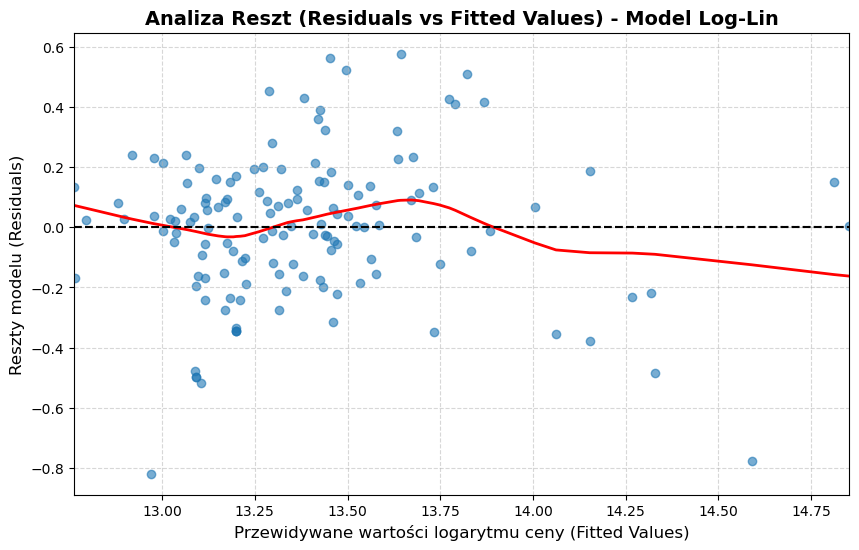

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- DIAGNOSTYKA MODELU ---\n")

# 1. Obliczenie VIF
print("1. Wskaźnik VIF (Sprawdzanie współliniowości):")
vif_data = pd.DataFrame()
vif_data["Zmienna"] = X_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]

# Pokazujemy wyniki bez stałej (const nie ma interpretacji we współliniowości)
display(vif_data[vif_data["Zmienna"] != "const"].round(2))
print("Złota zasada: VIF poniżej 5 (a idealnie poniżej 2) oznacza brak problemów ze współliniowością!\n")

# 2. Wykres reszt (Residuals vs Fitted)
print("2. Wykres reszt (Sprawdzanie homoskedastyczności):")
fig, ax = plt.subplots(figsize=(10, 6))

fitted_vals = model_ols.fittedvalues
residuals = model_ols.resid

# Wykres z LOWESS z Twojego kodu (super podejście)
sns.residplot(
    x=fitted_vals, 
    y=residuals, 
    lowess=True, 
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, 
    line_kws={'color': 'red', 'lw': 2}
)

ax.set_title('Analiza Reszt (Residuals vs Fitted Values) - Model Log-Lin', fontsize=14, fontweight='bold')
ax.set_xlabel('Przewidywane wartości logarytmu ceny (Fitted Values)', fontsize=12)
ax.set_ylabel('Reszty modelu (Residuals)', fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()